# How the NLB spreadsheet is measured

1. **What is in NLB?** The public DANDI NWBs plus the released test ground truth (`eval_data_test.h5`).
2. **From that, how do we get the spreadsheet numbers?** Trials, neurons, length, raw size, benchmark size.

## 1. What is in NLB

- Seven datasets, four monkeys. **Sorted single units**, not FALCON threshold crossings.
- MC_Maze / Large / Medium / Small are **four separate sessions of Jenkins** (different dates), not subsets. One row each.
- Each dataset = one session = two NWBs:
  - **train** — all units (with `units/heldout` flag), behavior, trials labelled `train` / `val` (Area2, DMFC also `none`).
  - **test** — held-in units only, `split=test`, no behavior.
- **`eval_data_test.h5`** (nlb_tools, released Jan 2026) — the formerly private test ground truth: held-out test spikes, 200 ms forward windows, test behavior. One group per dataset, each stored twice (5 ms and `_20` = 20 ms bins).

**Keep vs ditch (BENCHMARK size) = the minimum NLB evaluation needs**

- NLB scoring ([`nlb_tools/evaluation.py`](https://github.com/neurallatents/nlb_tools/blob/main/nlb_tools/evaluation.py)):
  - co-smoothing — held-out test spikes (`eval_spikes_heldout`);
  - decoding — velocity (hand for Maze/Area2, finger for RTT) via `train_behavior` / `eval_behavior` + decode masks; DMFC uses `tp` via `eval_behavior`;
  - PSTH R² — `psth`, `eval_cond_idx`, `eval_jitter`;
  - forward prediction — `eval_spikes_heldin_forward`, `eval_spikes_heldout_forward`.
- Models are fit on NWB spikes + trial tables.
- **Keep:** NWB units + trial tables + small metadata; the 5 ms eval-H5 arrays the evaluator reads.
- **Ditch:**
  - all 1 kHz NWB behavior — the scored velocity is already in the eval H5, binned; the rest (eye, cursor, position; Area2 muscle / joint / force) is never scored;
  - the `_20` H5 copy (same data at 20 ms);
  - H5 arrays the evaluator never reads (`train_cond_idx`, `train_jitter`, DMFC `train_spikes_heldout`);
  - NWB schemas.

## 2. How those files become spreadsheet numbers

- **SUBJECTS** — biological animals (Jenkins, Indy, Han, Haydn). 1 per row.
- **TRIALS** — NLB-used trials: `train` + `val` + `test`. `split=none` rows are failed trials (Area2 `result` A/I; DMFC outliers / no response) → NOTES only.
- **NEURONS** — `len(units/id)` in the train NWB. Held-out neurons are a **subset** of this, not extra.
- **CHANNELS** — `N/A`. Sorted units are the source of truth; channels are only for threshold-crossing datasets. Recording hardware (arrays / probes, electrode count) goes in NOTES.
- **LENGTH** — time inside NLB-used trials: union of train/val trial windows + test trial windows + 200 ms forward window per test trial. Inter-trial time excluded. Train and test NWBs have separate clocks (both start at 0), so they add. Forward windows come from the 5 ms H5 group only.
- **RAW** — train + test NWB file sizes + this dataset's arrays in the eval H5 (both bin sizes: that is what was downloaded).
- **BENCHMARK** — on-disk HDF5 bytes of the kept arrays (list above). Each eval-H5 array is counted once.
- **BASIC STATS** — one firing rate per sorted unit over the **same windows as LENGTH**:
  - train/val — NWB spikes;
  - test — test NWB (held-in units) or `eval_spikes_heldout` (held-out units);
  - forward — `eval_spikes_*_forward`.
  - Exception: DMFC held-out test spikes are NaN-padded in the H5 (only ~0.2–0.5 s of each 1.7 s trial), so those units use the bins actually covered.
  - One session per row, so no across-session plot.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

here = Path.cwd().resolve()
REPO = here
for candidate in [here, *here.parents]:
    if (candidate / "src" / "ladys").is_dir() or (candidate / "data" / "nlb").exists():
        REPO = candidate
        break
ROOT = REPO / "data" / "nlb"
EVAL_H5 = ROOT / "eval_test" / "eval_data_test.h5"
assert ROOT.exists() and EVAL_H5.exists(), (
    f"Expected NLB NWBs and eval ground truth under {ROOT}"
)
FIGURE_DIR = REPO / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GB, MB = 1e9, 1e6
RASTER_SECONDS = 2.0
H5_BIN = 0.005  # seconds per bin in the 5 ms H5 groups

# Paper table values (NLB'21 appendix) used as assertions.
# train = train + val trials in the train NWB.
DATASETS = {
    "MC_Maze":        dict(folder="MC_Maze",        h5="mc_maze",        subject="Jenkins", behavior=["hand_vel"],   train=2295, test=574, heldin=137, heldout=45),
    "MC_Maze Large":  dict(folder="MC_Maze_Large",  h5="mc_maze_large",  subject="Jenkins", behavior=["hand_vel"],   train=500,  test=100, heldin=122, heldout=40),
    "MC_Maze Medium": dict(folder="MC_Maze_Medium", h5="mc_maze_medium", subject="Jenkins", behavior=["hand_vel"],   train=250,  test=100, heldin=114, heldout=38),
    "MC_Maze Small":  dict(folder="MC_Maze_Small",  h5="mc_maze_small",  subject="Jenkins", behavior=["hand_vel"],   train=100,  test=100, heldin=107, heldout=35),
    "MC_RTT":         dict(folder="MC_RTT",         h5="mc_rtt",         subject="Indy",    behavior=["finger_vel"], train=1080, test=272, heldin=98,  heldout=32),  # paper: 271 test
    "Area2_Bump":     dict(folder="Area2_Bump",     h5="area2_bump",     subject="Han",     behavior=["hand_vel"],   train=364,  test=98,  heldin=49,  heldout=16),
    "DMFC_RSG":       dict(folder="DMFC_RSG",       h5="dmfc_rsg",       subject="Haydn",   behavior=[],             train=1006, test=283, heldin=40,  heldout=14),  # tp is in the trial table
}
# Recording hardware (paper appendix), checked against the NWB electrode table.
HARDWARE = {
    "MC_Maze": ("two 96-electrode Utah arrays (M1, PMd)", 192),
    "MC_Maze Large": ("two 96-electrode Utah arrays (M1, PMd)", 192),
    "MC_Maze Medium": ("two 96-electrode Utah arrays (M1, PMd)", 192),
    "MC_Maze Small": ("two 96-electrode Utah arrays (M1, PMd)", 192),
    "MC_RTT": ("one 96-electrode Utah array (M1)", 96),
    "Area2_Bump": ("one 96-electrode Utah array (area 2, S1)", 96),
    "DMFC_RSG": ("three Plexon probes (DMFC), 3 x 24 electrodes", 72),
}
# Eval-H5 arrays read by nlb_tools.evaluation.evaluate (5 ms groups).
H5_GROUND_TRUTH = {"eval_spikes_heldout", "eval_spikes_heldin_forward", "eval_spikes_heldout_forward", "eval_behavior"}
H5_EVALUATOR = H5_GROUND_TRUTH | {"train_behavior", "train_decode_mask", "eval_decode_mask", "psth", "eval_cond_idx", "eval_jitter"}


def as_text(values) -> np.ndarray:
    return np.array([v.decode() if isinstance(v, bytes) else v for v in values])


def nwb_paths(name: str) -> dict[str, Path]:
    paths = sorted((ROOT / DATASETS[name]["folder"]).rglob("*.nwb"))
    return {"train": next(p for p in paths if "train" in p.name), "test": next(p for p in paths if "test" in p.name)}


def ragged(f: h5py.File, name: str) -> list[np.ndarray]:
    values, stops = f[name][:], f[name + "_index"][:].astype(int)
    return [values[a:b] for a, b in zip(np.r_[0, stops[:-1]], stops)]


def union(intervals) -> np.ndarray:
    iv = np.asarray(intervals, dtype=float).reshape(-1, 2)
    iv = iv[np.argsort(iv[:, 0])]
    merged: list[list[float]] = []
    for a, b in iv:
        if merged and a <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], b)
        else:
            merged.append([a, b])
    return np.array(merged).reshape(-1, 2)


def seconds(intervals: np.ndarray) -> float:
    return float((intervals[:, 1] - intervals[:, 0]).sum())


def trial_windows(f: h5py.File, splits: set[str]) -> np.ndarray:
    split = as_text(f["intervals/trials/split"][:])
    keep = np.isin(split, list(splits))
    return union(np.c_[f["intervals/trials/start_time"][:][keep], f["intervals/trials/stop_time"][:][keep]])


def count_inside(times: np.ndarray, windows: np.ndarray) -> int:
    times = np.sort(times)
    return int((np.searchsorted(times, windows[:, 1]) - np.searchsorted(times, windows[:, 0])).sum())


def nwb_status(path: str, name: str) -> str:
    if path.startswith("specifications/"):
        return "schema (excluded)"
    if path.startswith("processing/behavior/"):
        if path.split("/")[2] in DATASETS[name]["behavior"]:
            return "dropped: 1 kHz scored behavior (binned copy kept in eval H5)"
        return "dropped: unscored behavior"
    return "kept: NWB spikes / trials / metadata"


def h5_status(group: str, key: str) -> str:
    if group.endswith("_20"):
        return "dropped: 20 ms duplicate"
    if key in H5_GROUND_TRUTH:
        return "kept: test ground truth"
    if key in H5_EVALUATOR:
        return "kept: evaluator input"
    return "dropped: not read by evaluator"


def storage_table(name: str) -> pd.DataFrame:
    """One row per stored array (NWB datasets + this dataset's eval H5 arrays)."""
    rows = []
    for kind, path in nwb_paths(name).items():
        with h5py.File(path, "r") as f:
            def add(p, obj):
                if isinstance(obj, h5py.Dataset):
                    rows.append({"source": f"{kind} NWB", "array": p, "bytes": obj.id.get_storage_size(), "status": nwb_status(p, name)})
            f.visititems(add)
    with h5py.File(EVAL_H5, "r") as f:
        h5 = DATASETS[name]["h5"]
        for group in (h5, h5 + "_20"):
            if group in f:
                for key, obj in f[group].items():
                    rows.append({"source": "eval H5", "array": f"{group}/{key}", "bytes": obj.id.get_storage_size(), "status": h5_status(group, key)})
    return pd.DataFrame(rows)


def audit(name: str) -> dict[str, object]:
    """Every spreadsheet quantity for one dataset, with the paper-table assertions."""
    meta, paths = DATASETS[name], nwb_paths(name)
    with h5py.File(paths["train"], "r") as tr, h5py.File(paths["test"], "r") as te, h5py.File(EVAL_H5, "r") as ev:
        ids, heldout = tr["units/id"][:], tr["units/heldout"][:].astype(bool)
        test_ids = te["units/id"][:]
        splits = Counter(as_text(tr["intervals/trials/split"][:]).tolist()) + Counter(as_text(te["intervals/trials/split"][:]).tolist())
        used = trial_windows(tr, {"train", "val"})
        test = trial_windows(te, {"test"})
        g = ev[meta["h5"]]
        eval_ho = np.asarray(g["eval_spikes_heldout"], dtype=float)          # (test trials, bins, held-out units)
        fwd_hi = np.asarray(g["eval_spikes_heldin_forward"], dtype=float)    # (test trials, 40, held-in units)
        fwd_ho = np.asarray(g["eval_spikes_heldout_forward"], dtype=float)
        obs = union(np.concatenate(ragged(tr, "units/obs_intervals")))
        train_counts = np.array([count_inside(t, used) for t in ragged(tr, "units/spike_times")])
        test_counts_hi = np.array([count_inside(t, test) for t in ragged(te, "units/spike_times")])
        n_electrodes = len(tr["general/extracellular_ephys/electrodes/id"])
        session = tr["session_start_time"][()].decode()[:10]

    n_test = splits["test"]
    forward_s = fwd_hi.shape[1] * H5_BIN
    covered = lambda x: (~np.isnan(x)).sum(axis=(0, 1)) * H5_BIN  # seconds of non-NaN bins per unit

    # Rates over the same windows as LENGTH. H5 columns follow NWB unit order
    # (held-in = test-NWB order, held-out = train-NWB order); checked in the independent audit.
    spikes = train_counts.astype(float)
    window = np.full(len(ids), seconds(used))
    hi, ho = np.flatnonzero(~heldout), np.flatnonzero(heldout)
    spikes[hi] += test_counts_hi + np.nansum(fwd_hi, axis=(0, 1))
    window[hi] += seconds(test) + covered(fwd_hi)
    spikes[ho] += np.nansum(eval_ho, axis=(0, 1)) + np.nansum(fwd_ho, axis=(0, 1))
    window[ho] += covered(eval_ho) + covered(fwd_ho)
    rates = pd.DataFrame({"unit": ids, "heldout": heldout, "spikes": spikes, "seconds": window, "rate_hz": spikes / window})
    storage = storage_table(name)
    raw_bytes = sum(p.stat().st_size for p in paths.values()) + storage.loc[storage.source == "eval H5", "bytes"].sum()

    # Checks against the paper and between files.
    assert splits["train"] + splits["val"] == meta["train"], splits
    assert n_test == meta["test"] == eval_ho.shape[0] == fwd_hi.shape[0]
    assert (~heldout).sum() == meta["heldin"] == fwd_hi.shape[-1]
    assert heldout.sum() == meta["heldout"] == eval_ho.shape[-1] == fwd_ho.shape[-1]
    assert np.array_equal(test_ids, ids[~heldout]), "test NWB must hold exactly the held-in units, in train order"
    assert np.isclose(forward_s, 0.2) and not np.isnan(fwd_hi).any() and not np.isnan(fwd_ho).any()
    assert n_electrodes == HARDWARE[name][1], (name, n_electrodes)
    assert np.isclose(window[hi], seconds(used) + seconds(test) + n_test * forward_s).all()
    # Held-out units: full LENGTH window except DMFC, whose H5 test spikes are NaN-padded.
    assert name == "DMFC_RSG" or np.isclose(window[ho], seconds(used) + seconds(test) + n_test * forward_s).all()

    return {
        "name": name,
        "session": session,
        "electrodes": n_electrodes,
        "splits": dict(splits),
        "trials": int(splits["train"] + splits["val"] + n_test),
        "failed": int(splits.get("none", 0)),
        "neurons": int(len(ids)),
        "heldout": int(heldout.sum()),
        "train_s": seconds(used),
        "test_s": seconds(test),
        "forward_s": n_test * forward_s,
        "all_recorded_s": seconds(obs) + seconds(test),
        "raw_bytes": int(raw_bytes),
        "benchmark_bytes": int(storage.loc[storage.status.str.startswith("kept"), "bytes"].sum()),
        "ground_truth_bytes": int(storage.loc[storage.status == "kept: test ground truth", "bytes"].sum()),
        "storage": storage,
        "rates": rates,
        "used_windows": used,
    }


def length_min(a: dict) -> float:
    return (a["train_s"] + a["test_s"] + a["forward_s"]) / 60


def show_audit(a: dict) -> None:
    print(f"{a['name']}  session {a['session']}  splits {a['splits']}")
    print(f"TRIALS     train+val+test                 {a['trials']}   (failed split=none: {a['failed']})")
    print(f"NEURONS    len(units/id), train NWB       {a['neurons']}   (held-out subset: {a['heldout']})")
    print(f"LENGTH     train/val trial windows        {a['train_s']:.1f} s")
    print(f"           + test trial windows           {a['test_s']:.1f} s")
    print(f"           + 200 ms forward × test trials {a['forward_s']:.1f} s")
    print(f"           = {length_min(a):.2f} min   (all recorded time incl. inter-trial: {a['all_recorded_s'] / 60:.2f} min, not used)")
    print(f"RAW        NWBs + eval H5 share           {a['raw_bytes'] / GB:.3f} GB")
    print(f"BENCHMARK  kept arrays                    {a['benchmark_bytes'] / GB:.3f} GB   (of which test ground truth {a['ground_truth_bytes'] / MB:.1f} MB)")
    print(f"HARDWARE   {HARDWARE[a['name']][0]}; {a['electrodes']} electrodes in NWB (NOTES only)")


def show_storage(a: dict, top: int = 8) -> None:
    """Biggest arrays and what happens to them; then totals per status."""
    s = a["storage"].sort_values("bytes", ascending=False)
    view = s.head(top).assign(MB=lambda d: (d.bytes / MB).round(2)).drop(columns="bytes")
    display(view.reset_index(drop=True))
    display((s.groupby("status")["bytes"].sum() / MB).round(2).rename("MB").to_frame())


def plot_raster(a: dict) -> None:
    """First RASTER_SECONDS of the train NWB (t = 0 = recording start), all sorted units."""
    name = a["name"]
    with h5py.File(nwb_paths(name)["train"], "r") as f:
        spikes = [t[(t >= 0) & (t < RASTER_SECONDS)] for t in ragged(f, "units/spike_times")]
    fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
    for a0, b0 in a["used_windows"]:
        if a0 < RASTER_SECONDS and b0 > 0:
            ax.axvspan(max(a0, 0), min(b0, RASTER_SECONDS), color="#4C78A8", alpha=0.08, lw=0)
    ax.eventplot(spikes, colors="black", linewidths=0.35, linelengths=0.8)
    ax.set(xlim=(0, RASTER_SECONDS), ylim=(-0.5, len(spikes) - 0.5), xlabel="Time from recording start (s)", ylabel="Sorted unit (file order)",
           title=f"NLB {name} — first {RASTER_SECONDS:.0f} s of train NWB (all {len(spikes)} sorted units; shaded = NLB-used trials)")
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    out = FIGURE_DIR / f"nlb_{DATASETS[name]['folder'].lower()}_raster.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()


def plot_rates(a: dict) -> tuple[float, float]:
    name, values = a["name"], a["rates"]["rate_hz"].to_numpy()
    mean, median = float(values.mean()), float(np.median(values))
    positive = values[values > 0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, scale, bins, data in (
        (axes[0], "linear", 40, values),
        (axes[1], "log", np.logspace(np.log10(positive.min()), np.log10(positive.max()), 40), positive),
    ):
        ax.hist(data, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.4)
        ax.axvline(mean, color="#E45756", lw=2, label=f"Mean = {mean:.2f} Hz")
        ax.axvline(median, color="#54A24B", lw=2, ls="--", label=f"Median = {median:.2f} Hz")
        ax.set(xscale=scale, xlabel="Unit firing rate (spikes/s)", ylabel="Sorted units", title=f"{scale} x")
        ax.legend(frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"NLB {name} — firing rate per sorted unit (N = {len(values)}, same windows as LENGTH)")
    fig.savefig(FIGURE_DIR / f"nlb_{DATASETS[name]['folder'].lower()}_unit_rates.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"N={len(values)}  mean={mean:.2f} Hz  median={median:.2f} Hz  silent={(values == 0).sum()}")
    return mean, median


def run(name: str) -> dict:
    a = audit(name)
    show_audit(a)
    show_storage(a)
    plot_raster(a)
    a["mean_hz"], a["median_hz"] = plot_rates(a)
    return a

Files on disk: one train + one test NWB per dataset, plus the shared eval H5 (one group per dataset × 2 bin sizes).

In [2]:
rows = []
for name in DATASETS:
    for kind, path in nwb_paths(name).items():
        with h5py.File(path, "r") as f:
            rows.append({
                "dataset": name, "kind": kind, "file": path.name,
                "subject": f["general/subject/subject_id"][()].decode(),
                "session": f["session_start_time"][()].decode()[:10],
                "units": len(f["units/id"]), "held-out flagged": int(f["units/heldout"][:].sum()),
                "splits": dict(Counter(as_text(f["intervals/trials/split"][:]).tolist())),
                "MB": round(path.stat().st_size / MB, 2),
            })
display(pd.DataFrame(rows))
with h5py.File(EVAL_H5, "r") as f:
    print("eval H5 groups:", list(f.keys()))
print(f"eval H5 file: {EVAL_H5.stat().st_size / MB:.1f} MB")

,dataset,kind,file,subject,session,units,held-out flagged,splits,MB
0,MC_Maze,train,sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb,Jenkins,2009-09-25,182,45,"{'val': 574, 'train': 1721}",690.61
1,MC_Maze,test,sub-Jenkins_ses-full_desc-test_ecephys.nwb,Jenkins,2009-09-25,137,0,{'test': 574},3.39
2,MC_Maze Large,train,sub-Jenkins_ses-large_desc-train_behavior+ecephys.nwb,Jenkins,2009-10-06,162,40,"{'train': 375, 'val': 125}",148.59
3,MC_Maze Large,test,sub-Jenkins_ses-large_desc-test_ecephys.nwb,Jenkins,2009-10-06,122,0,{'test': 100},0.80
4,MC_Maze Medium,train,sub-Jenkins_ses-medium_desc-train_behavior+ecephys.nwb,Jenkins,2009-09-29,152,38,"{'val': 62, 'train': 188}",76.60
5,MC_Maze Medium,test,sub-Jenkins_ses-medium_desc-test_ecephys.nwb,Jenkins,2009-09-29,114,0,{'test': 100},0.70
6,MC_Maze Small,train,sub-Jenkins_ses-small_desc-train_behavior+ecephys.nwb,Jenkins,2009-09-28,142,35,"{'val': 25, 'train': 75}",29.21
7,MC_Maze Small,test,sub-Jenkins_ses-small_desc-test_ecephys.nwb,Jenkins,2009-09-28,107,0,{'test': 100},0.69
8,MC_RTT,train,sub-Indy_desc-train_behavior+ecephys.nwb,Indy,2017-02-02,130,32,"{'train': 810, 'val': 270}",49.76
9,MC_RTT,test,sub-Indy_desc-test_ecephys.nwb,Indy,2017-02-02,98,0,{'test': 272},1.20


eval H5 groups: ['area2_bump', 'area2_bump_20', 'dmfc_rsg', 'dmfc_rsg_20', 'mc_maze', 'mc_maze_20', 'mc_maze_large', 'mc_maze_large_20', 'mc_maze_medium', 'mc_maze_medium_20', 'mc_maze_small', 'mc_maze_small_20', 'mc_rtt', 'mc_rtt_20']
eval H5 file: 105.9 MB


## MC_Maze → spreadsheet row

- Jenkins, delayed center-out reaches through a maze. DANDI `000128`. Two 96-ch Utah arrays (PMd, M1).
- Unit IDs `1xxx` = PMd, `2xxx` = M1.

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `units/id` (train) | 182 sorted units | NEURONS |
| `units/heldout` | 45 held-out (subset) | NOTES |
| `units/spike_times` | spike times per unit | rates, raster, size |
| `intervals/trials` | `train` / `val` (train NWB), `test` (test NWB) | TRIALS, LENGTH |
| `processing/behavior/hand_vel` | 1 kHz hand velocity (scored) | **dropped** — same velocity kept binned in eval H5 `train_behavior` / `eval_behavior` |
| `processing/behavior/{hand_pos, cursor_pos, eye_pos}` | 1 kHz, ~490 MB | **dropped** (never scored) |
| eval H5 `mc_maze/eval_*` | held-out test spikes, forward windows, test behavior | **kept** (ground truth) |
| eval H5 `mc_maze/{train_behavior, psth, *_mask, eval_cond_idx}` | evaluator inputs | **kept** |

**Sums**

- **TRIALS** — 1,721 train + 574 val + 574 test = 2,869.
- **LENGTH** — Maze obs intervals = trial windows, so no inter-trial time to drop.

MC_Maze  session 2009-09-25  splits {'val': 574, 'train': 1721, 'test': 574}
TRIALS     train+val+test                 2869   (failed split=none: 0)
NEURONS    len(units/id), train NWB       182   (held-out subset: 45)
LENGTH     train/val trial windows        6809.9 s
           + test trial windows           401.8 s
           + 200 ms forward × test trials 114.8 s
           = 122.11 min   (all recorded time incl. inter-trial: 120.20 min, not used)
RAW        NWBs + eval H5 share           0.731 GB
BENCHMARK  kept arrays                    0.070 GB   (of which test ground truth 16.2 MB)
HARDWARE   two 96-electrode Utah arrays (M1, PMd); 192 electrodes in NWB (NOTES only)


,source,array,status,MB
0,train NWB,processing/behavior/hand_pos/data,dropped: unscored behavior,108.96
1,train NWB,processing/behavior/cursor_pos/data,dropped: unscored behavior,108.96
2,train NWB,processing/behavior/hand_vel/data,dropped: 1 kHz scored behavior (binned copy kept in eval H5),108.96
3,train NWB,processing/behavior/eye_pos/data,dropped: unscored behavior,108.96
4,train NWB,processing/behavior/hand_pos/timestamps,dropped: unscored behavior,54.48
5,train NWB,processing/behavior/eye_pos/timestamps,dropped: unscored behavior,54.48
6,train NWB,processing/behavior/cursor_pos/timestamps,dropped: unscored behavior,54.48
7,train NWB,processing/behavior/hand_vel/timestamps,dropped: 1 kHz scored behavior (binned copy kept in eval H5),54.48


,MB
status,
dropped: 1 kHz scored behavior (binned copy kept in eval H5),163.44
dropped: 20 ms duplicate,7.46
dropped: not read by evaluator,0.00
dropped: unscored behavior,490.31
kept: NWB spikes / trials / metadata,39.70
kept: evaluator input,13.58
kept: test ground truth,16.23
schema (excluded),0.00


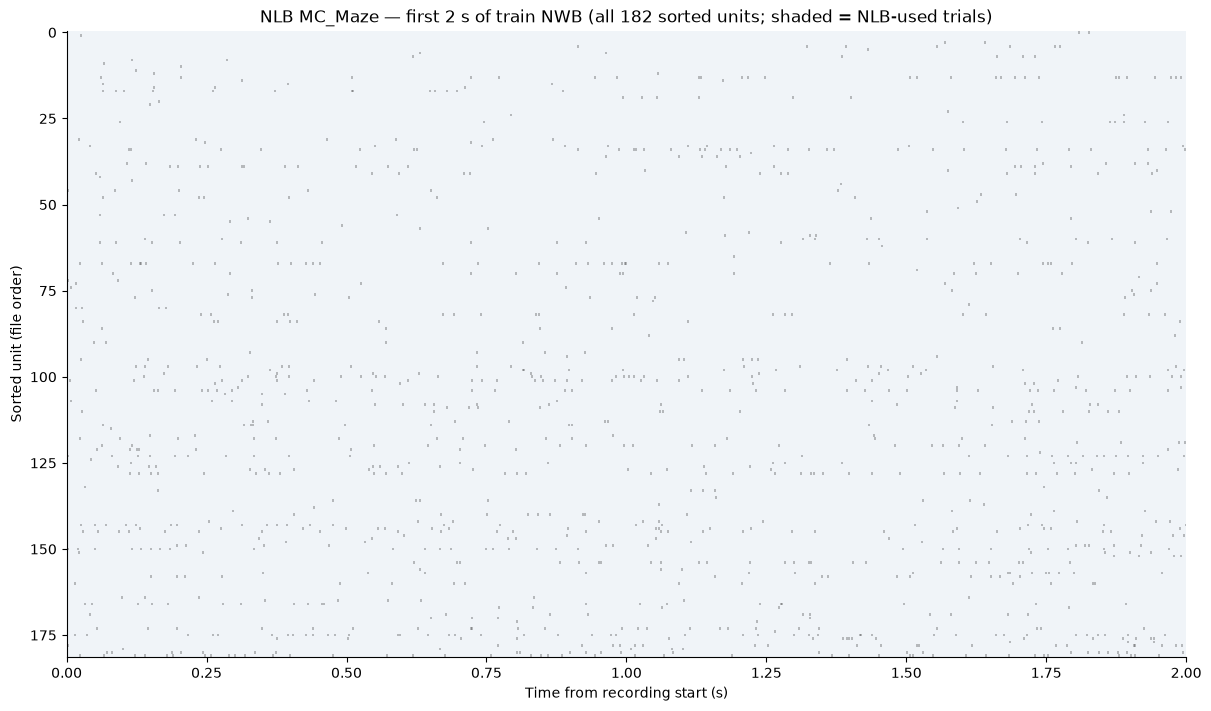

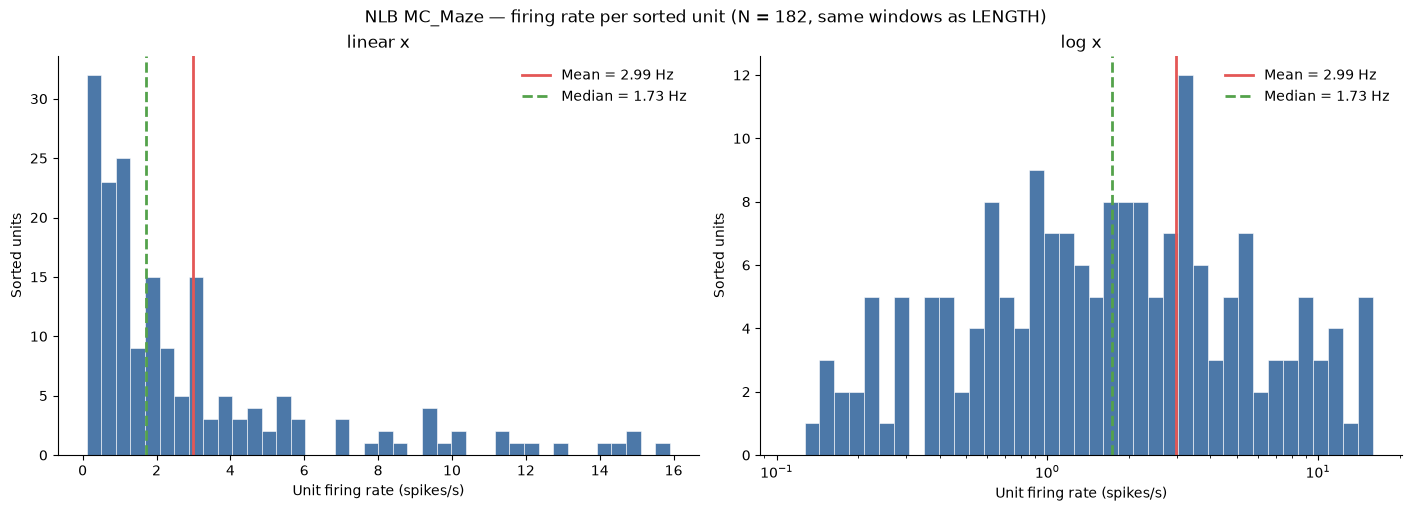

N=182  mean=2.99 Hz  median=1.73 Hz  silent=0


In [3]:
maze = run("MC_Maze")

## MC_Maze Large → spreadsheet row

- Separate Jenkins session (2009-10-06). DANDI `000138`. Same fields as MC_Maze. 500 train/val + 100 test.

MC_Maze Large  session 2009-10-06  splits {'train': 375, 'val': 125, 'test': 100}
TRIALS     train+val+test                 600   (failed split=none: 0)
NEURONS    len(units/id), train NWB       162   (held-out subset: 40)
LENGTH     train/val trial windows        1453.3 s
           + test trial windows           70.0 s
           + 200 ms forward × test trials 20.0 s
           = 25.72 min   (all recorded time incl. inter-trial: 25.39 min, not used)
RAW        NWBs + eval H5 share           0.156 GB
BENCHMARK  kept arrays                    0.015 GB   (of which test ground truth 2.5 MB)
HARDWARE   two 96-electrode Utah arrays (M1, PMd); 192 electrodes in NWB (NOTES only)


,source,array,status,MB
0,train NWB,processing/behavior/eye_pos/data,dropped: unscored behavior,23.25
1,train NWB,processing/behavior/cursor_pos/data,dropped: unscored behavior,23.25
2,train NWB,processing/behavior/hand_pos/data,dropped: unscored behavior,23.25
3,train NWB,processing/behavior/hand_vel/data,dropped: 1 kHz scored behavior (binned copy kept in eval H5),23.25
4,train NWB,processing/behavior/hand_pos/timestamps,dropped: unscored behavior,11.63
5,train NWB,processing/behavior/hand_vel/timestamps,dropped: 1 kHz scored behavior (binned copy kept in eval H5),11.63
6,train NWB,processing/behavior/cursor_pos/timestamps,dropped: unscored behavior,11.63
7,train NWB,processing/behavior/eye_pos/timestamps,dropped: unscored behavior,11.63


,MB
status,
dropped: 1 kHz scored behavior (binned copy kept in eval H5),34.88
dropped: 20 ms duplicate,1.39
dropped: not read by evaluator,0.00
dropped: unscored behavior,104.64
kept: NWB spikes / trials / metadata,9.38
kept: evaluator input,3.01
kept: test ground truth,2.53
schema (excluded),0.00


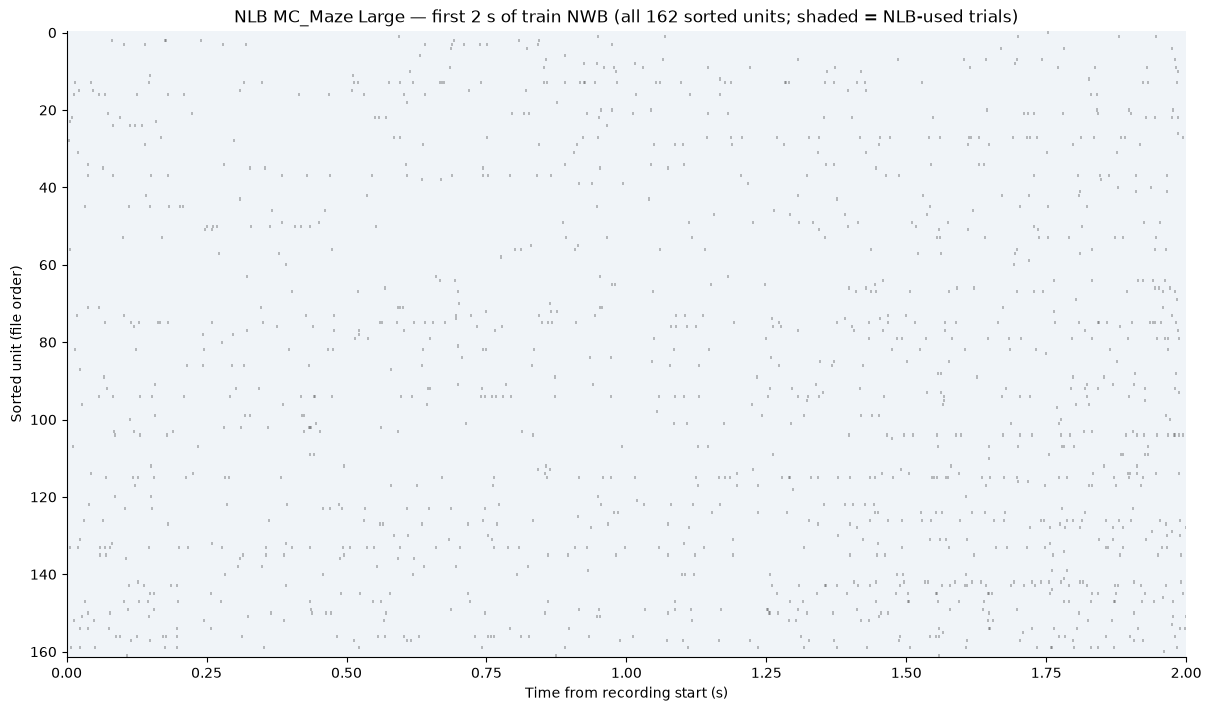

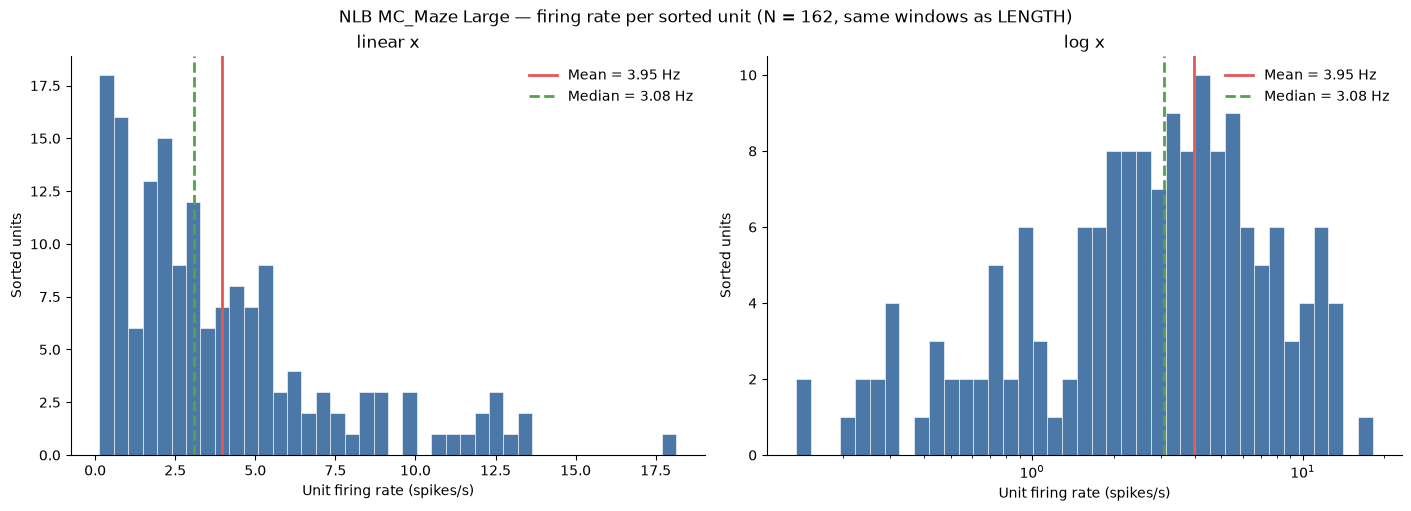

N=162  mean=3.95 Hz  median=3.08 Hz  silent=0


In [4]:
maze_l = run("MC_Maze Large")

## MC_Maze Medium → spreadsheet row

- Separate Jenkins session (2009-09-29). DANDI `000139`. 250 train/val + 100 test.

MC_Maze Medium  session 2009-09-29  splits {'val': 62, 'train': 188, 'test': 100}
TRIALS     train+val+test                 350   (failed split=none: 0)
NEURONS    len(units/id), train NWB       152   (held-out subset: 38)
LENGTH     train/val trial windows        757.4 s
           + test trial windows           70.0 s
           + 200 ms forward × test trials 20.0 s
           = 14.12 min   (all recorded time incl. inter-trial: 13.79 min, not used)
RAW        NWBs + eval H5 share           0.084 GB
BENCHMARK  kept arrays                    0.009 GB   (of which test ground truth 2.4 MB)
HARDWARE   two 96-electrode Utah arrays (M1, PMd); 192 electrodes in NWB (NOTES only)


,source,array,status,MB
0,train NWB,processing/behavior/cursor_pos/data,dropped: unscored behavior,12.12
1,train NWB,processing/behavior/eye_pos/data,dropped: unscored behavior,12.12
2,train NWB,processing/behavior/hand_vel/data,dropped: 1 kHz scored behavior (binned copy kept in eval H5),12.12
3,train NWB,processing/behavior/hand_pos/data,dropped: unscored behavior,12.12
4,train NWB,processing/behavior/cursor_pos/timestamps,dropped: unscored behavior,6.06
5,train NWB,processing/behavior/hand_vel/timestamps,dropped: 1 kHz scored behavior (binned copy kept in eval H5),6.06
6,train NWB,processing/behavior/hand_pos/timestamps,dropped: unscored behavior,6.06
7,train NWB,processing/behavior/eye_pos/timestamps,dropped: unscored behavior,6.06


,MB
status,
dropped: 1 kHz scored behavior (binned copy kept in eval H5),18.18
dropped: 20 ms duplicate,1.24
dropped: not read by evaluator,0.00
dropped: unscored behavior,54.54
kept: NWB spikes / trials / metadata,4.10
kept: evaluator input,2.58
kept: test ground truth,2.39
schema (excluded),0.00


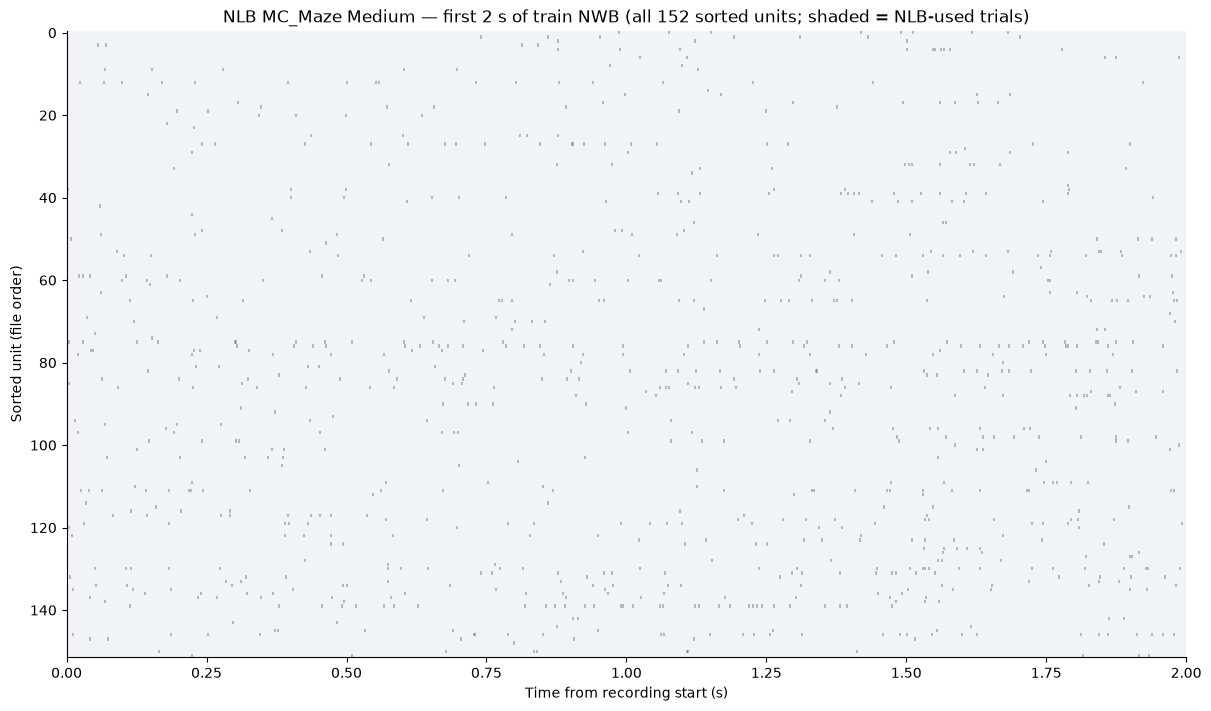

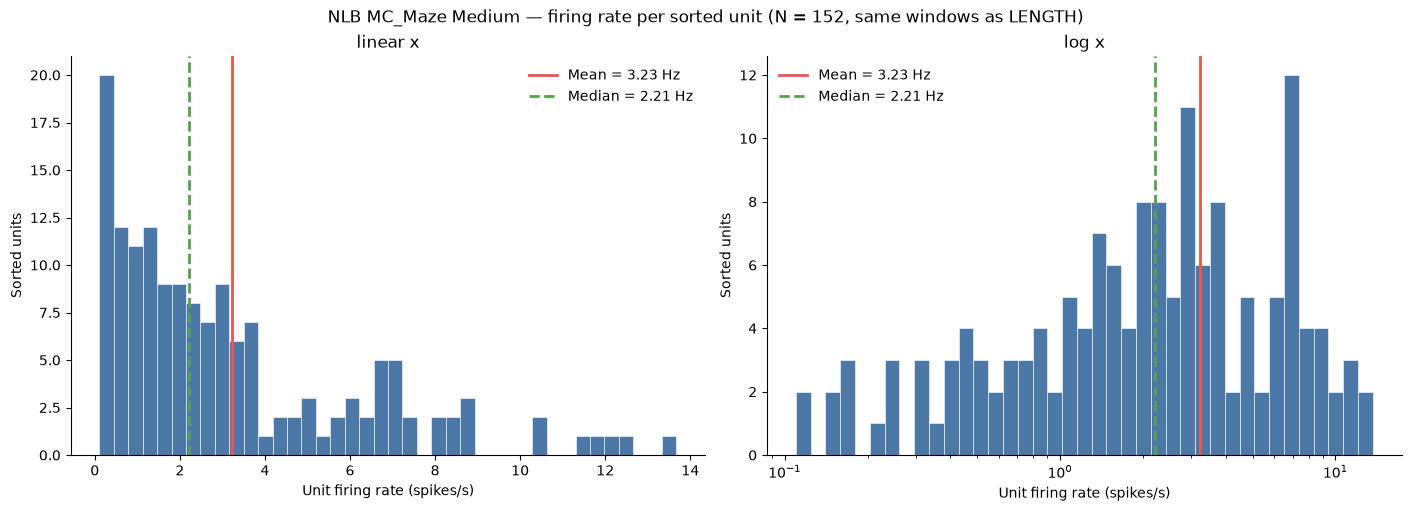

N=152  mean=3.23 Hz  median=2.21 Hz  silent=0


In [5]:
maze_m = run("MC_Maze Medium")

## MC_Maze Small → spreadsheet row

- Separate Jenkins session (2009-09-28). DANDI `000140`. 100 train/val + 100 test.

MC_Maze Small  session 2009-09-28  splits {'val': 25, 'train': 75, 'test': 100}
TRIALS     train+val+test                 200   (failed split=none: 0)
NEURONS    len(units/id), train NWB       142   (held-out subset: 35)
LENGTH     train/val trial windows        287.7 s
           + test trial windows           70.0 s
           + 200 ms forward × test trials 20.0 s
           = 6.30 min   (all recorded time incl. inter-trial: 5.96 min, not used)
RAW        NWBs + eval H5 share           0.036 GB
BENCHMARK  kept arrays                    0.006 GB   (of which test ground truth 2.2 MB)
HARDWARE   two 96-electrode Utah arrays (M1, PMd); 192 electrodes in NWB (NOTES only)


,source,array,status,MB
0,train NWB,processing/behavior/eye_pos/data,dropped: unscored behavior,4.6
1,train NWB,processing/behavior/hand_pos/data,dropped: unscored behavior,4.6
2,train NWB,processing/behavior/cursor_pos/data,dropped: unscored behavior,4.6
3,train NWB,processing/behavior/hand_vel/data,dropped: 1 kHz scored behavior (binned copy kept in eval H5),4.6
4,train NWB,processing/behavior/cursor_pos/timestamps,dropped: unscored behavior,2.3
5,train NWB,processing/behavior/hand_pos/timestamps,dropped: unscored behavior,2.3
6,train NWB,processing/behavior/hand_vel/timestamps,dropped: 1 kHz scored behavior (binned copy kept in eval H5),2.3
7,train NWB,processing/behavior/eye_pos/timestamps,dropped: unscored behavior,2.3


,MB
status,
dropped: 1 kHz scored behavior (binned copy kept in eval H5),6.91
dropped: 20 ms duplicate,1.12
dropped: not read by evaluator,0.00
dropped: unscored behavior,20.72
kept: NWB spikes / trials / metadata,1.80
kept: evaluator input,2.26
kept: test ground truth,2.23
schema (excluded),0.00


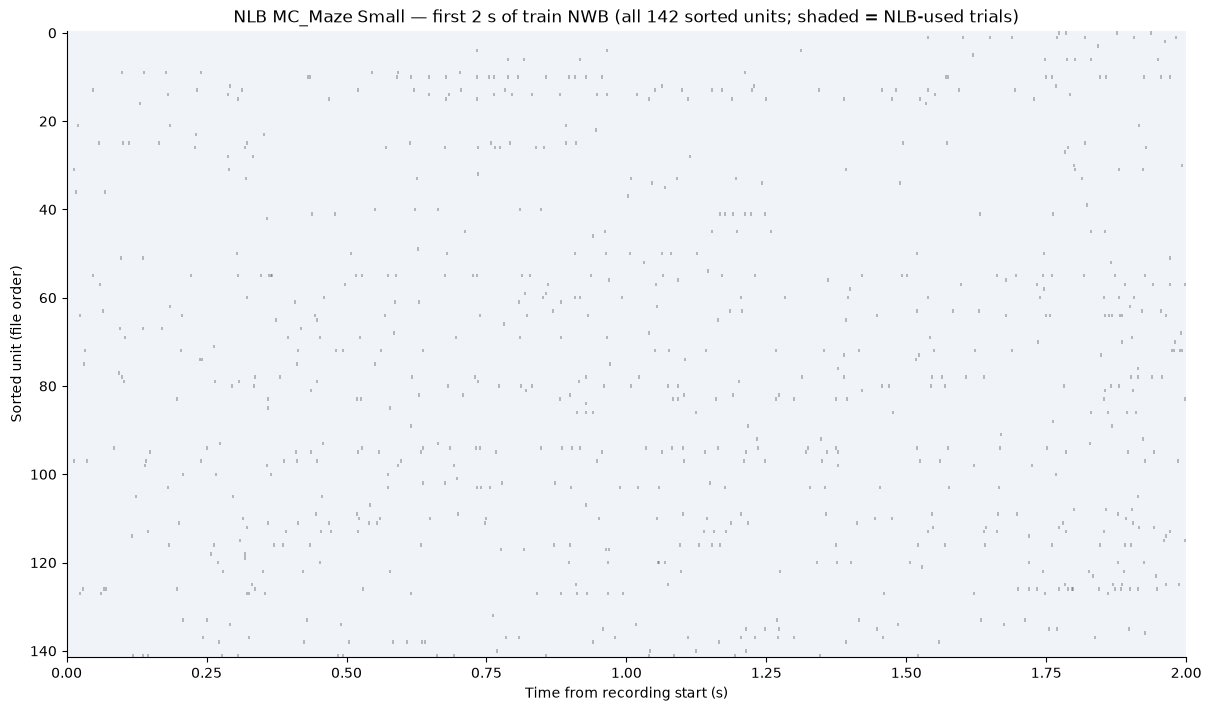

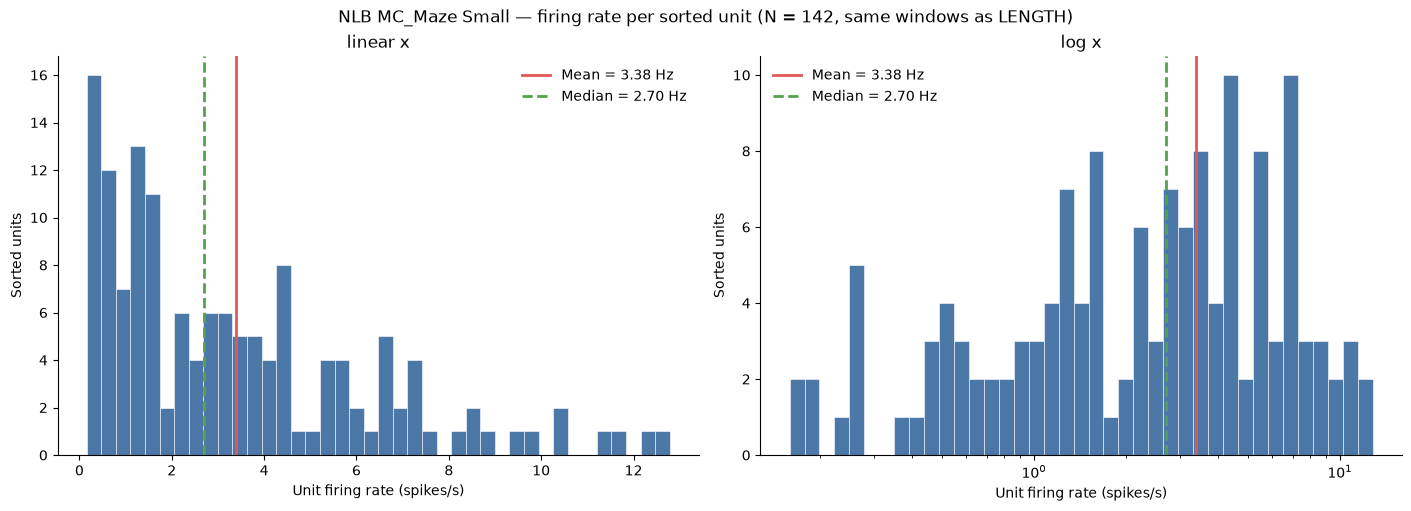

N=142  mean=3.38 Hz  median=2.70 Hz  silent=0


In [6]:
maze_s = run("MC_Maze Small")

## MC_RTT → spreadsheet row

- Indy, self-paced random-target reaching. DANDI `000129`. One 96-ch Utah array (M1).
- Continuous reaching cut into 600 ms "trials".

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `units/id` | 130 sorted units (32 held-out) | NEURONS |
| `intervals/trials` | 600 ms snippets | TRIALS, LENGTH |
| `processing/behavior/finger_vel` | 1 kHz finger velocity (scored) | **dropped** — binned copy kept in eval H5 |
| `processing/behavior/{finger_pos, cursor_pos, target_pos}` | | **dropped** |

**Paper vs files**

- Paper: 1,351 trials (271 test), session 2017-07-02. Files and eval H5: **1,352 (272 test)**, NWB date 2017-02-02.
- Use file trial count (paper may have dropped one trial for QC); use paper date in NOTES.

MC_RTT  session 2017-02-02  splits {'train': 810, 'val': 270, 'test': 272}
TRIALS     train+val+test                 1352   (failed split=none: 0)
NEURONS    len(units/id), train NWB       130   (held-out subset: 32)
LENGTH     train/val trial windows        648.0 s
           + test trial windows           163.2 s
           + 200 ms forward × test trials 54.4 s
           = 14.43 min   (all recorded time incl. inter-trial: 13.53 min, not used)
RAW        NWBs + eval H5 share           0.059 GB
BENCHMARK  kept arrays                    0.010 GB   (of which test ground truth 5.2 MB)
HARDWARE   one 96-electrode Utah array (M1); 96 electrodes in NWB (NOTES only)


,source,array,status,MB
0,train NWB,processing/behavior/finger_pos/data,dropped: unscored behavior,15.58
1,train NWB,processing/behavior/target_pos/data,dropped: unscored behavior,10.39
2,train NWB,processing/behavior/finger_vel/data,dropped: 1 kHz scored behavior (binned copy kept in eval H5),10.39
3,train NWB,processing/behavior/cursor_pos/data,dropped: unscored behavior,10.39
4,train NWB,units/spike_times,kept: NWB spikes / trials / metadata,2.72
5,eval H5,mc_rtt/eval_spikes_heldin_forward,kept: test ground truth,2.13
6,eval H5,mc_rtt/eval_spikes_heldout,kept: test ground truth,2.09
7,eval H5,mc_rtt/train_behavior,kept: evaluator input,1.04


,MB
status,
dropped: 1 kHz scored behavior (binned copy kept in eval H5),10.39
dropped: 20 ms duplicate,1.55
dropped: unscored behavior,36.35
kept: NWB spikes / trials / metadata,3.76
kept: evaluator input,1.04
kept: test ground truth,5.18
schema (excluded),0.00


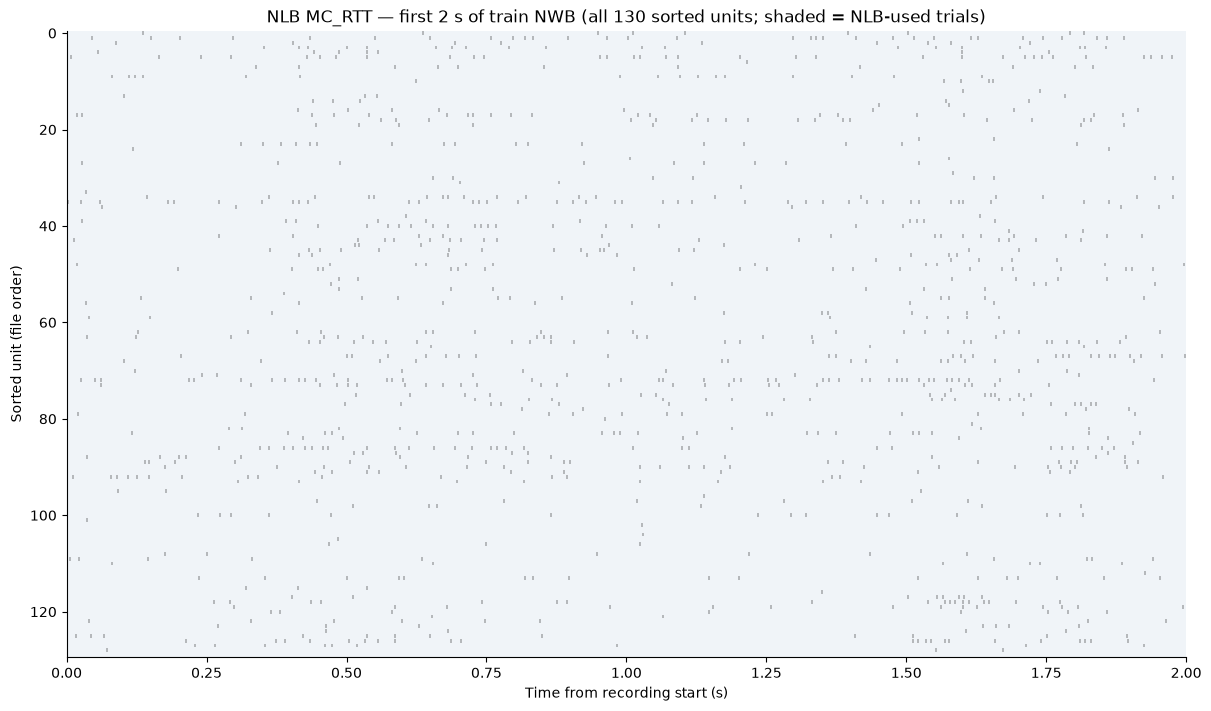

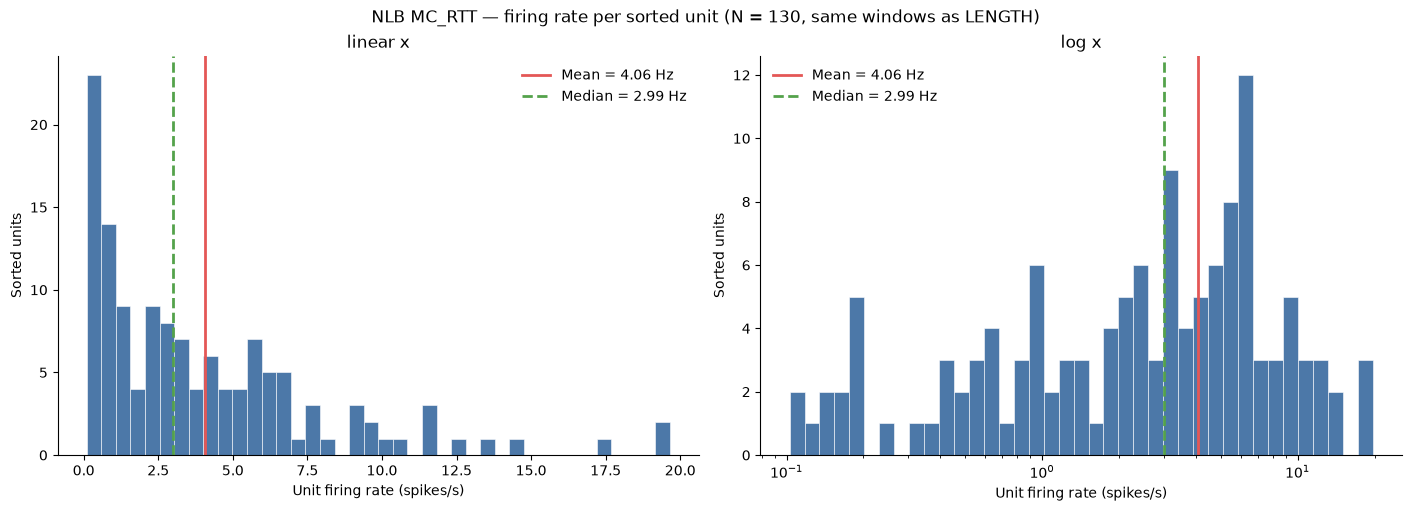

N=130  mean=4.06 Hz  median=2.99 Hz  silent=0


In [7]:
rtt = run("MC_RTT")

## Area2_Bump → spreadsheet row

- Han, center-out reaches with mechanical bumps. DANDI `000127`. One 96-ch Utah array (area 2, S1).
- **462 `split=none` trials** = failed (`result` A = aborted 390, I = incomplete 72). Train/val are all `R` (rewarded).

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `units/id` | 65 sorted units (16 held-out) | NEURONS |
| `intervals/trials/result` | R / A / I | why `none` is excluded |
| `processing/behavior/hand_vel` | 1 kHz hand velocity (scored) | **dropped** — binned copy kept in eval H5 |
| `processing/behavior/{muscle_len, muscle_vel, joint_ang, joint_vel, force, hand_pos}` | ~1.78 GB at 1 kHz | **dropped** (not scored; available for future decoding) |

**Sums**

- **TRIALS** — 272 train + 92 val + 98 test = 462.
- **LENGTH** — obs intervals include inter-trial and failed-trial time; only NLB-used trial windows count.

Area2_Bump  session 2017-12-07  splits {'val': 92, 'none': 462, 'train': 272, 'test': 98}
TRIALS     train+val+test                 462   (failed split=none: 462)
NEURONS    len(units/id), train NWB       65   (held-out subset: 16)
LENGTH     train/val trial windows        1056.4 s
           + test trial windows           58.8 s
           + 200 ms forward × test trials 19.6 s
           = 18.91 min   (all recorded time incl. inter-trial: 38.03 min, not used)
RAW        NWBs + eval H5 share           1.826 GB
BENCHMARK  kept arrays                    0.010 GB   (of which test ground truth 1.0 MB)
HARDWARE   one 96-electrode Utah array (area 2, S1); 96 electrodes in NWB (NOTES only)


,source,array,status,MB
0,train NWB,processing/behavior/muscle_vel/data,dropped: unscored behavior,693.72
1,train NWB,processing/behavior/muscle_len/data,dropped: unscored behavior,693.72
2,train NWB,processing/behavior/joint_ang/data,dropped: unscored behavior,124.51
3,train NWB,processing/behavior/joint_vel/data,dropped: unscored behavior,124.51
4,train NWB,processing/behavior/force/data,dropped: unscored behavior,106.73
5,train NWB,processing/behavior/hand_pos/data,dropped: unscored behavior,35.58
6,train NWB,processing/behavior/hand_vel/data,dropped: 1 kHz scored behavior (binned copy kept in eval H5),35.58
7,train NWB,units/spike_times,kept: NWB spikes / trials / metadata,8.14


,MB
status,
dropped: 1 kHz scored behavior (binned copy kept in eval H5),35.58
dropped: 20 ms duplicate,0.46
dropped: not read by evaluator,0.00
dropped: unscored behavior,1778.76
kept: NWB spikes / trials / metadata,8.53
kept: evaluator input,0.85
kept: test ground truth,0.98
schema (excluded),0.00


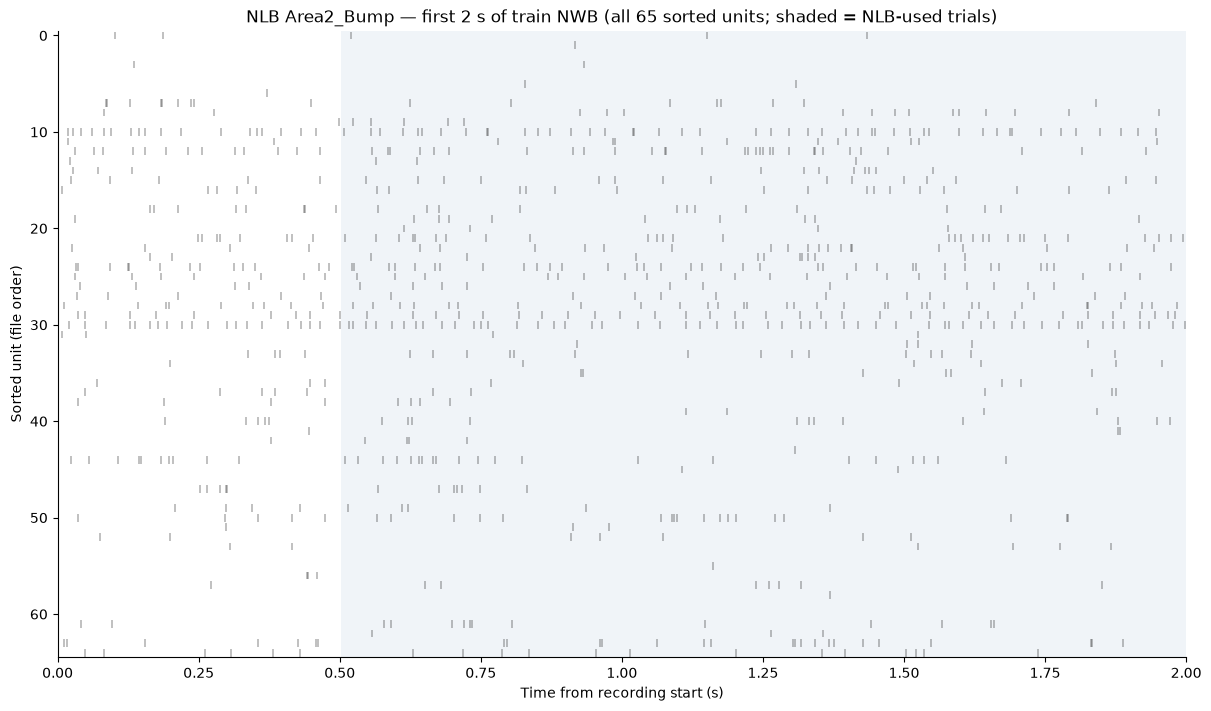

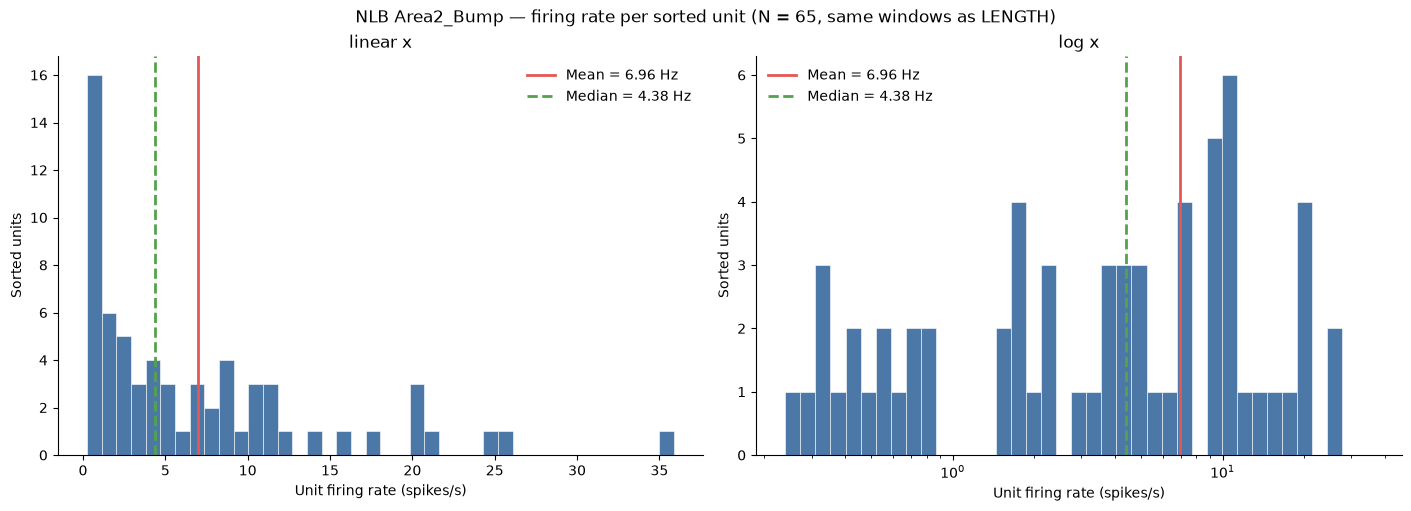

N=65  mean=6.96 Hz  median=4.38 Hz  silent=0


In [8]:
area2 = run("Area2_Bump")

In [9]:
# Why split=none is excluded: every none trial is aborted/incomplete.
with h5py.File(nwb_paths("Area2_Bump")["train"], "r") as f:
    t = pd.DataFrame({"split": as_text(f["intervals/trials/split"][:]), "result": as_text(f["intervals/trials/result"][:])})
display(pd.crosstab(t.result, t.split))

split,none,train,val
result,,,
A,390,0,0
I,72,0,0
R,0,272,92


## DMFC_RSG → spreadsheet row

- Haydn, ready-set-go interval reproduction. DANDI `000130`. Three Plexon probes (DMFC).
- **154 `split=none` trials** = failed (mostly `is_outlier`, missing Set/Go, some up to 124 s long).
- No behavior time series. `tp` is a trial-table column (train) and in eval H5 `eval_behavior` (test).

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `units/id` | 54 sorted units (14 held-out) | NEURONS |
| `intervals/trials/{tp, ts, is_outlier, …}` | timing + condition columns | TRIALS; `tp` = target |
| eval H5 `dmfc_rsg/eval_behavior` | test `tp` and conditions | **kept** (ground truth) |
| eval H5 `dmfc_rsg/{train_spikes_heldout, train_jitter}` | re-binned train data | **dropped** (not read by evaluator) |

**Sums**

- **TRIALS** — 748 train + 258 val + 283 test = 1,289.

DMFC_RSG  session 2016-12-11  splits {'train': 748, 'val': 258, 'none': 154, 'test': 283}
TRIALS     train+val+test                 1289   (failed split=none: 154)
NEURONS    len(units/id), train NWB       54   (held-out subset: 14)
LENGTH     train/val trial windows        3121.3 s
           + test trial windows           481.1 s
           + 200 ms forward × test trials 56.6 s
           = 60.98 min   (all recorded time incl. inter-trial: 88.17 min, not used)
RAW        NWBs + eval H5 share           0.048 GB
BENCHMARK  kept arrays                    0.024 GB   (of which test ground truth 6.0 MB)
HARDWARE   three Plexon probes (DMFC), 3 x 24 electrodes; 72 electrodes in NWB (NOTES only)


,source,array,status,MB
0,eval H5,dmfc_rsg/train_spikes_heldout,dropped: not read by evaluator,16.90
1,train NWB,units/spike_times,kept: NWB spikes / trials / metadata,13.65
2,eval H5,dmfc_rsg/eval_spikes_heldout,kept: test ground truth,4.75
3,eval H5,dmfc_rsg_20/train_spikes_heldout,dropped: 20 ms duplicate,4.23
4,eval H5,dmfc_rsg/psth,kept: evaluator input,2.59
5,eval H5,dmfc_rsg_20/eval_spikes_heldout,dropped: 20 ms duplicate,1.19
6,test NWB,units/spike_times,kept: NWB spikes / trials / metadata,1.13
7,eval H5,dmfc_rsg/eval_spikes_heldin_forward,kept: test ground truth,0.91


,MB
status,
dropped: 20 ms duplicate,6.40
dropped: not read by evaluator,16.91
kept: NWB spikes / trials / metadata,15.19
kept: evaluator input,2.61
kept: test ground truth,5.98
schema (excluded),0.00


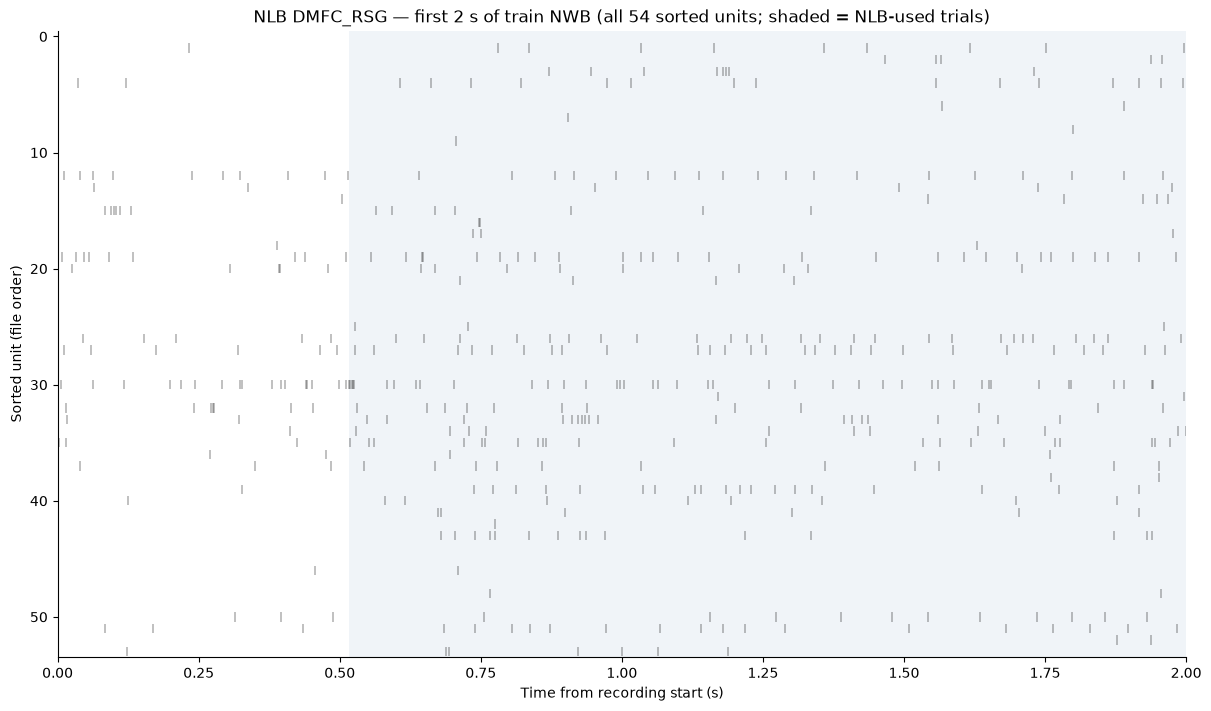

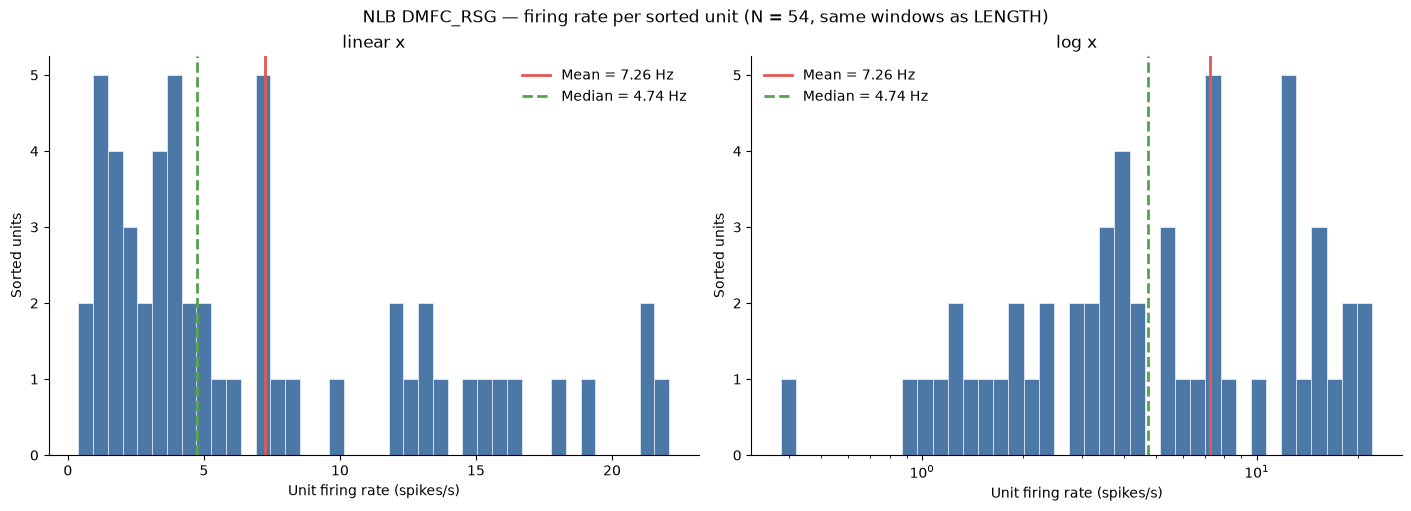

N=54  mean=7.26 Hz  median=4.74 Hz  silent=0


In [10]:
dmfc = run("DMFC_RSG")

In [11]:
with h5py.File(nwb_paths("DMFC_RSG")["train"], "r") as f:
    t = pd.DataFrame({"split": as_text(f["intervals/trials/split"][:]), "is_outlier": f["intervals/trials/is_outlier"][:].astype(bool),
                      "has_go": np.isfinite(f["intervals/trials/go_time"][:])})
display(pd.crosstab([t.is_outlier, t.has_go], t.split))

split              none  train  val
is_outlier has_go                  
False      True      17    720  246
True       False    131      0    0
           True       6     28   12

## Spreadsheet

- Same columns as the FALCON CSV. CHANNELS = `N/A` (sorted units).
- Length: 1 decimal minute. RAW / BENCHMARK: 3 decimal GB.
- Writes `tutorials/nlb_datasets.csv`.

In [12]:
UNSCORED = {
    "MC_Maze": "hand/cursor/eye position", "MC_Maze Large": "hand/cursor/eye position",
    "MC_Maze Medium": "hand/cursor/eye position", "MC_Maze Small": "hand/cursor/eye position",
    "MC_RTT": "finger/cursor/target position", "Area2_Bump": "muscle length/velocity, joint angle/velocity, force, hand position",
    "DMFC_RSG": None,
}
TARGET = {"MC_RTT": "finger velocity", "DMFC_RSG": "tp (trial table)"}


def notes(a: dict) -> str:
    name = a["name"]
    s = a["splits"]
    date = "2017-07-02 (paper; NWB says 2017-02-02)" if name == "MC_RTT" else a["session"]
    parts = [
        f"{DATASETS[name]['subject']}, session {date}",
        f"{s['train']} train + {s['val']} val + {s['test']} test trials",
        f"{a['heldout']} of {a['neurons']} neurons held out",
        f"{HARDWARE[name][0]} ({a['electrodes']} electrodes in NWB; CHANNELS N/A because units are sorted)",
        f"decoding target: {TARGET.get(name, 'hand velocity')}",
    ]
    if a["failed"]:
        parts.append(f"{a['failed']} failed split=none trials excluded")
    if UNSCORED[name]:
        dropped = a["storage"].loc[a["storage"].status == "dropped: unscored behavior", "bytes"].sum()
        parts.append(f"not in benchmark size: 1 kHz NWB behavior incl. unscored {UNSCORED[name]} ({dropped / GB:.3f} GB unscored)")
    parts.append(f"benchmark size includes {a['ground_truth_bytes'] / MB:.1f} MB released test ground truth (eval H5)")
    if name == "MC_RTT":
        parts.append("paper reports 1,351 trials / 271 test; files have 1,352 / 272")
    return "; ".join(parts) + "."


audits = [maze, maze_l, maze_m, maze_s, rtt, area2, dmfc]
inventory = pd.DataFrame([
    {
        "DATASET": a["name"],
        "ANIMAL": "Rhesus macaque",
        "SUBJECTS": 1,
        "TRIALS": a["trials"],
        "TOTAL CHANNELS": "N/A",
        "MEDIAN CHANNELS": "N/A",
        "TOTAL NEURONS": a["neurons"],
        "MEDIAN NEURONS": a["neurons"],
        "RECORDING LENGTH (min)": round(length_min(a), 1),
        "RAW DATASET SIZE (GB)": round(a["raw_bytes"] / GB, 3),
        "BENCHMARK DATASET SIZE (GB)": round(a["benchmark_bytes"] / GB, 3),
        "NOTES": notes(a),
        "BASIC STATS": f"Unit firing rate: mean {a['mean_hz']:.2f}, median {a['median_hz']:.2f} spikes/s",
    }
    for a in audits
])
display(inventory.drop(columns="NOTES"))
csv_path = REPO / "tutorials" / "nlb_datasets.csv"
inventory.to_csv(csv_path, index=False)
print("wrote", csv_path)

,DATASET,ANIMAL,SUBJECTS,TRIALS,TOTAL CHANNELS,MEDIAN CHANNELS,TOTAL NEURONS,MEDIAN NEURONS,RECORDING LENGTH (min),RAW DATASET SIZE (GB),BENCHMARK DATASET SIZE (GB),BASIC STATS
0,MC_Maze,Rhesus macaque,1,2869,N/A,N/A,182,182,122.1,0.731,0.070,"Unit firing rate: mean 2.99, median 1.73 spikes/s"
1,MC_Maze Large,Rhesus macaque,1,600,N/A,N/A,162,162,25.7,0.156,0.015,"Unit firing rate: mean 3.95, median 3.08 spikes/s"
2,MC_Maze Medium,Rhesus macaque,1,350,N/A,N/A,152,152,14.1,0.084,0.009,"Unit firing rate: mean 3.23, median 2.21 spikes/s"
3,MC_Maze Small,Rhesus macaque,1,200,N/A,N/A,142,142,6.3,0.036,0.006,"Unit firing rate: mean 3.38, median 2.70 spikes/s"
4,MC_RTT,Rhesus macaque,1,1352,N/A,N/A,130,130,14.4,0.059,0.010,"Unit firing rate: mean 4.06, median 2.99 spikes/s"
5,Area2_Bump,Rhesus macaque,1,462,N/A,N/A,65,65,18.9,1.826,0.010,"Unit firing rate: mean 6.96, median 4.38 spikes/s"
6,DMFC_RSG,Rhesus macaque,1,1289,N/A,N/A,54,54,61.0,0.048,0.024,"Unit firing rate: mean 7.26, median 4.74 spikes/s"


wrote /Users/ismaelrobles-razzaq/2_cs_projects/neural_latents_benchmark_2/tmp/ladys-publish/tutorials/nlb_datasets.csv
